In [ ]:
!pip install pydmd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.7/152.7 kB 3.3 MB/s eta 0:00:00


Loading data...
U shape: (1001, 5002)
P shape: (1001, 5002)
svd_rank: 100, A_tilde shape: (100, 100)
B_tilde shape: (100, 1001)
modes shape: (1001, 100)
svd_rank: 125, A_tilde shape: (125, 125)
B_tilde shape: (125, 1001)
modes shape: (1001, 125)
svd_rank: 150, A_tilde shape: (150, 150)
B_tilde shape: (150, 1001)
modes shape: (1001, 150)
DMD MAE: 0.029089, MAPE: 320.552691%
DMD Training Time: 3.965681 seconds, Prediction Time: 6.698219 seconds
DMDc MAE: 0.049209, MAPE: 2100.906332%
DMDc Training Time: 25.551167 seconds, Prediction Time: 0.852785 seconds


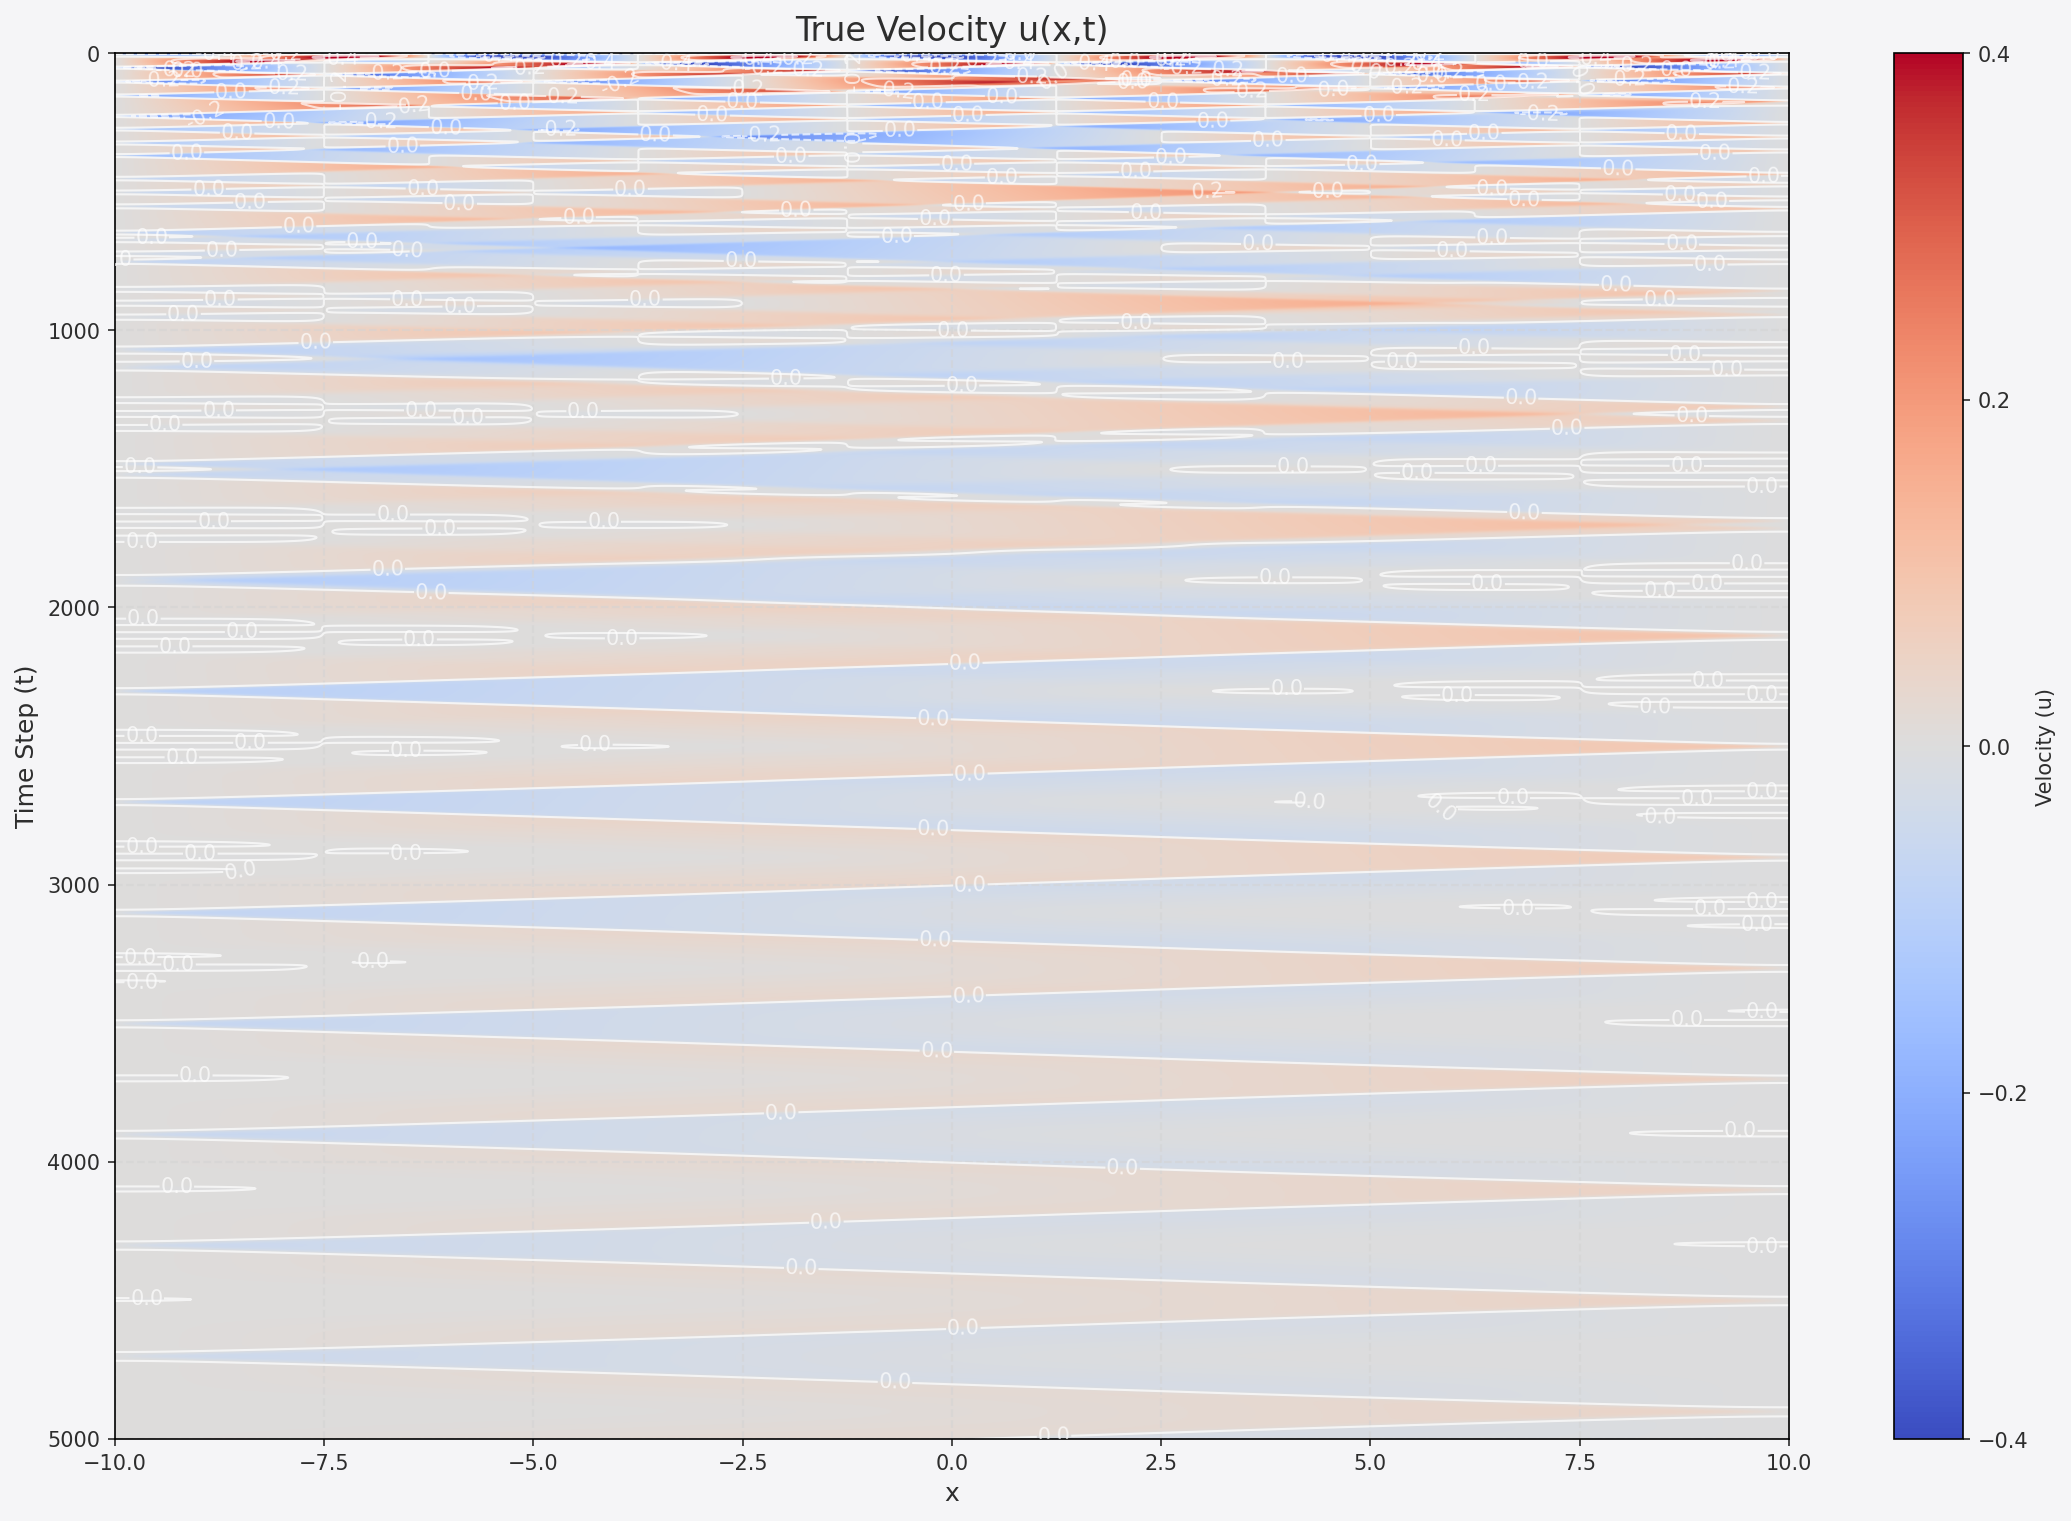

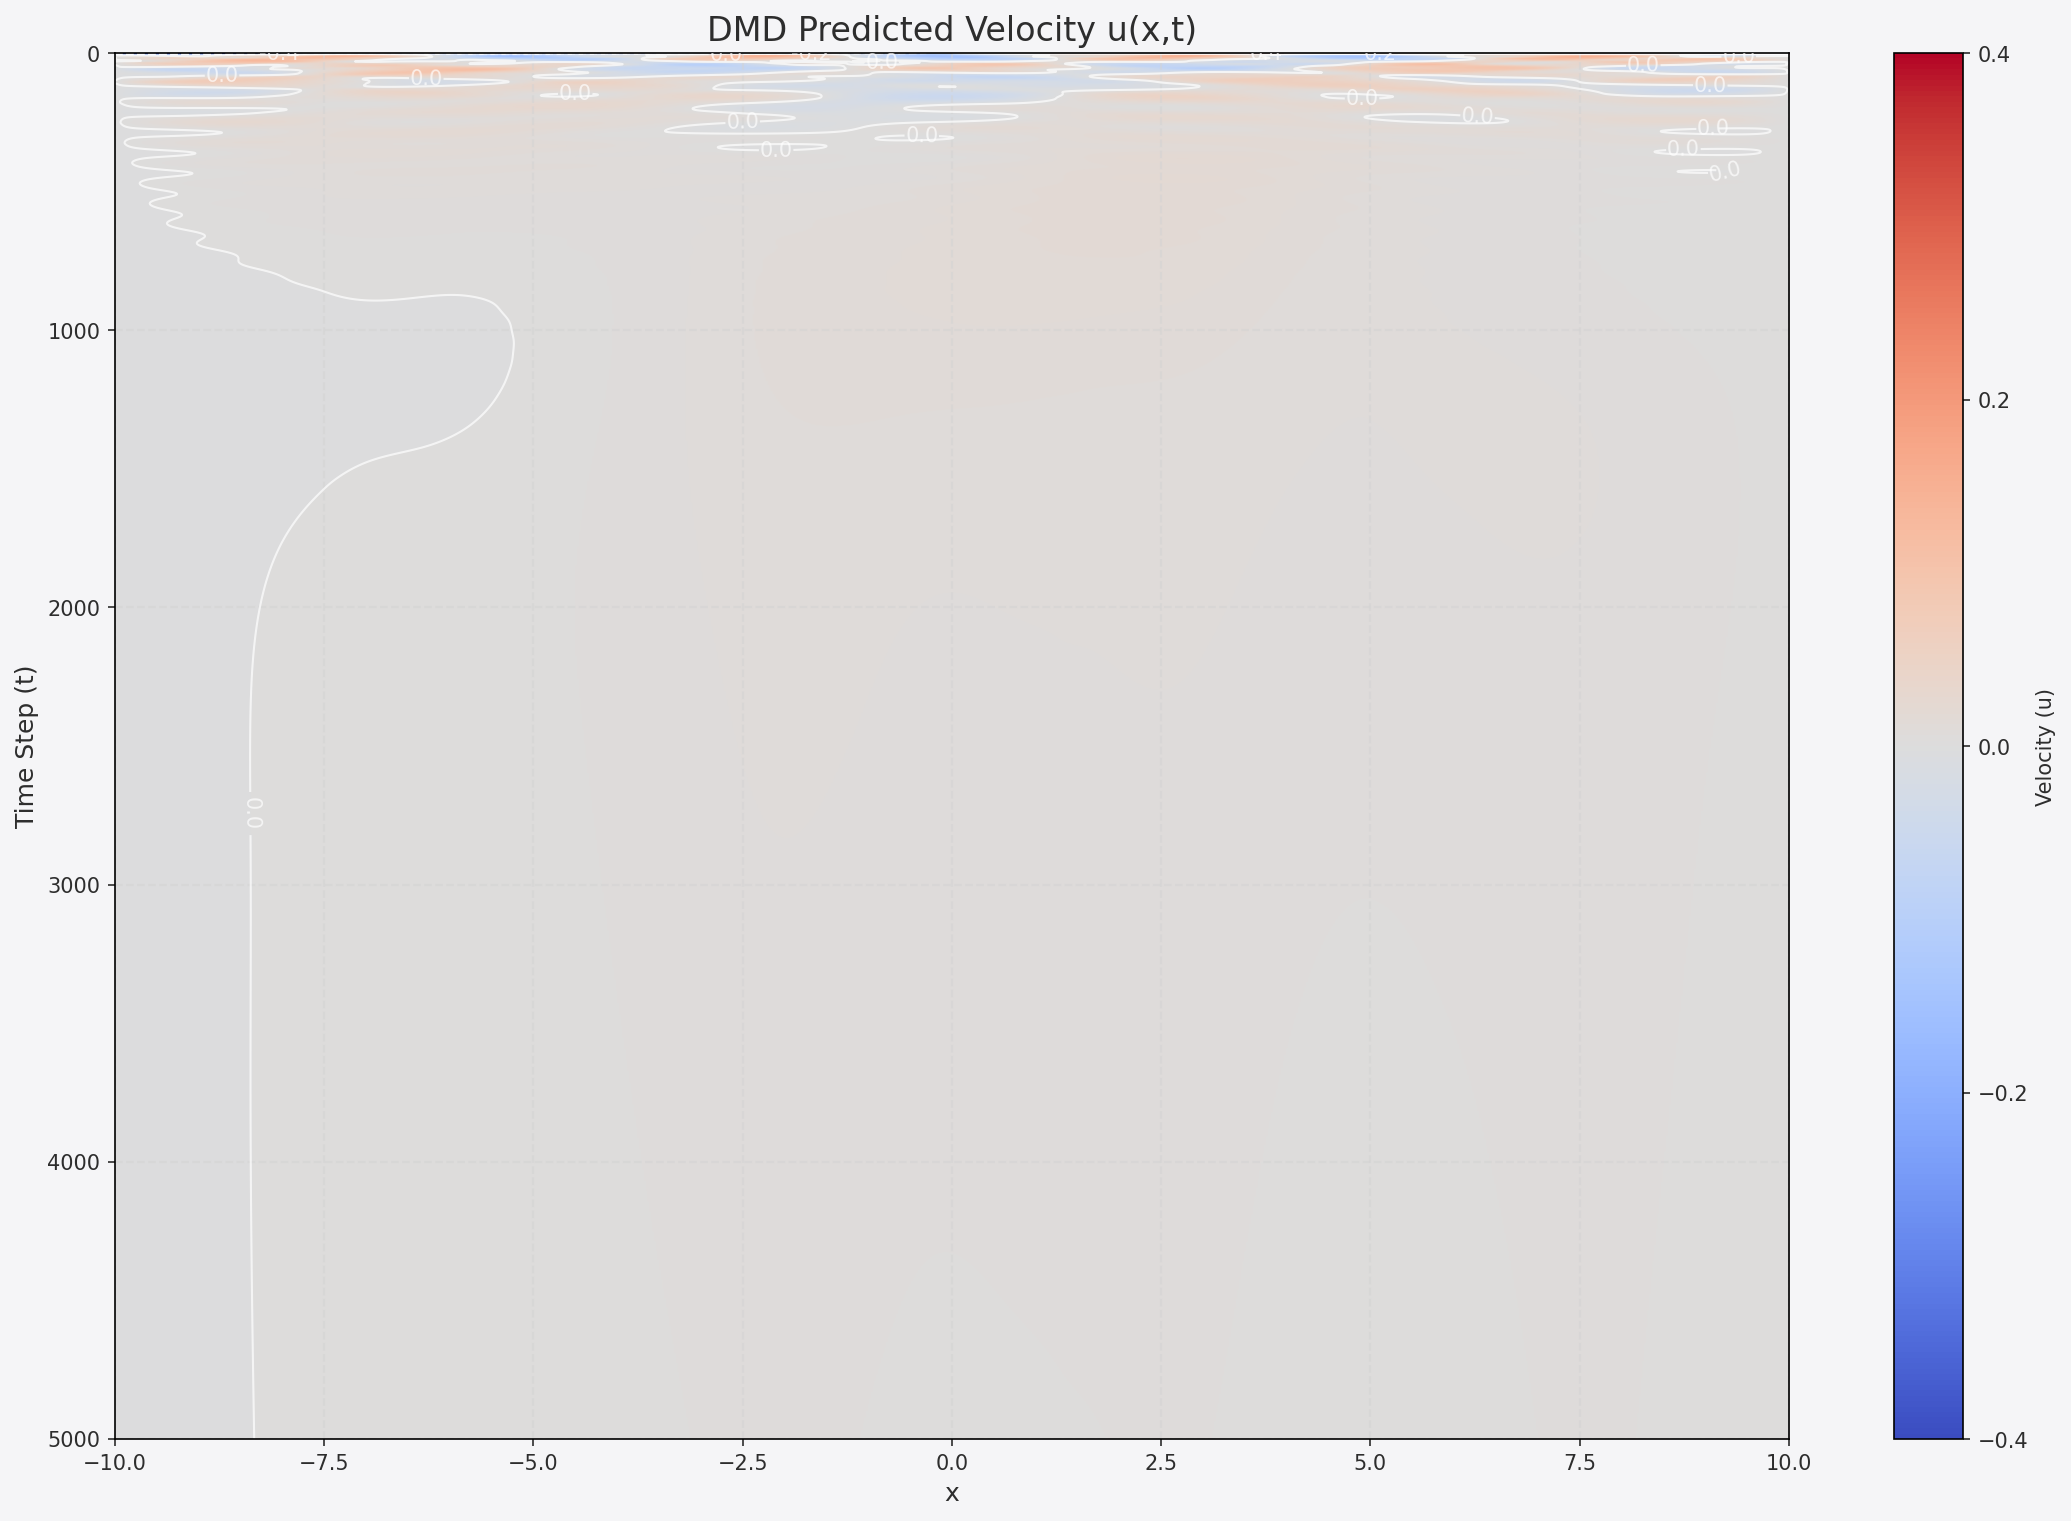

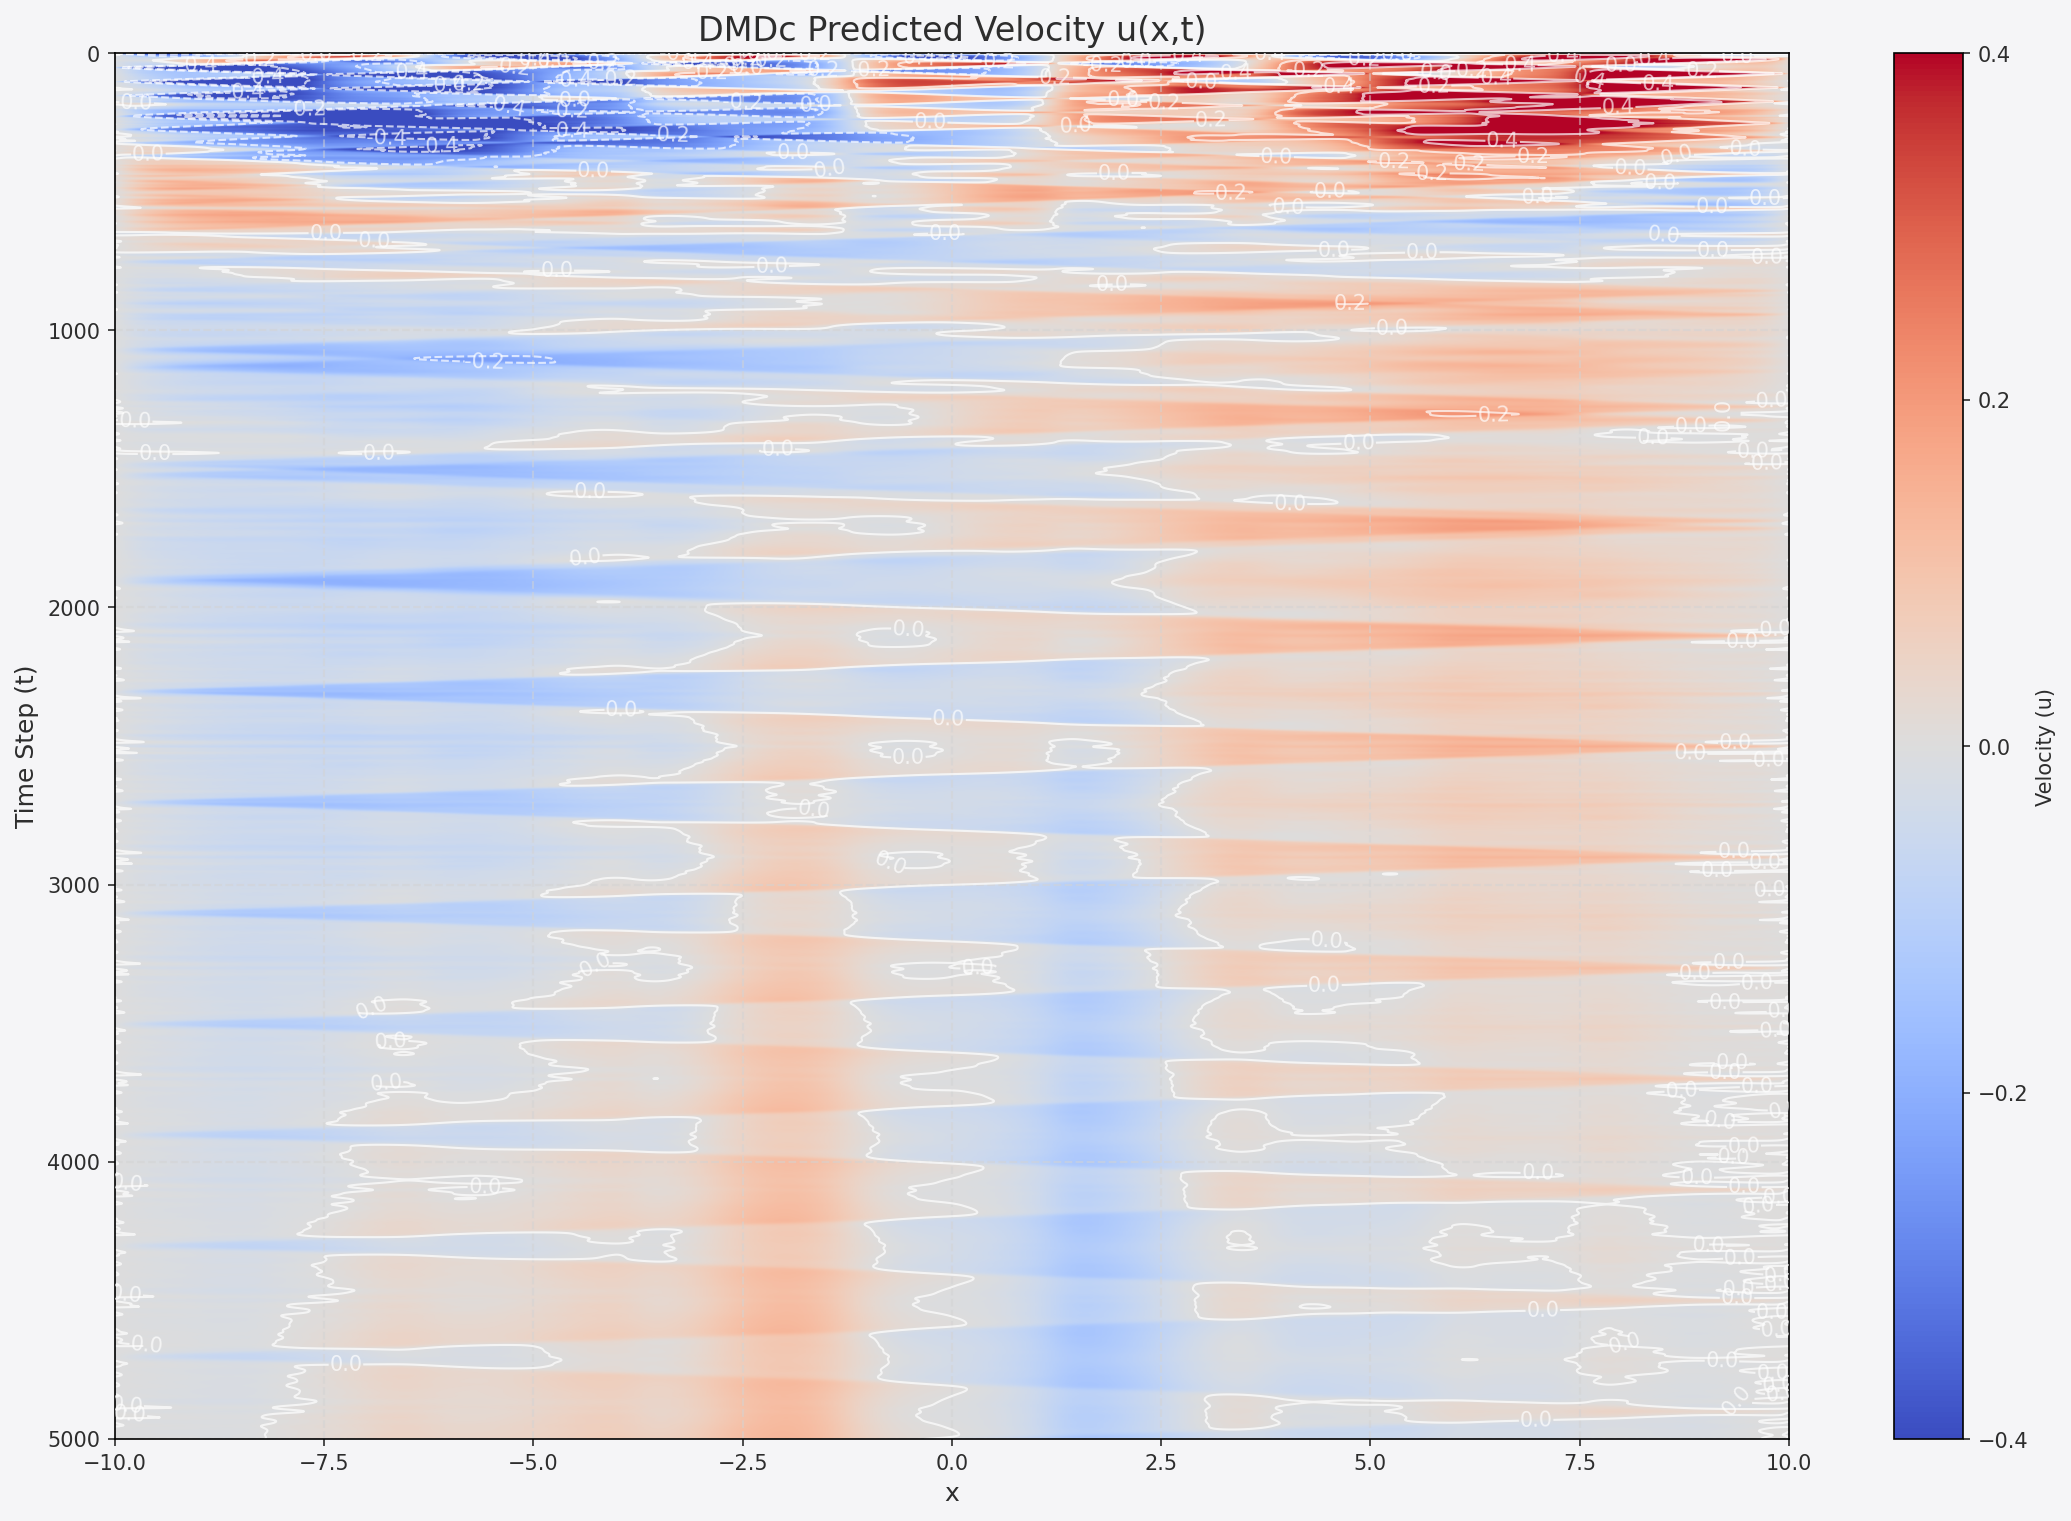

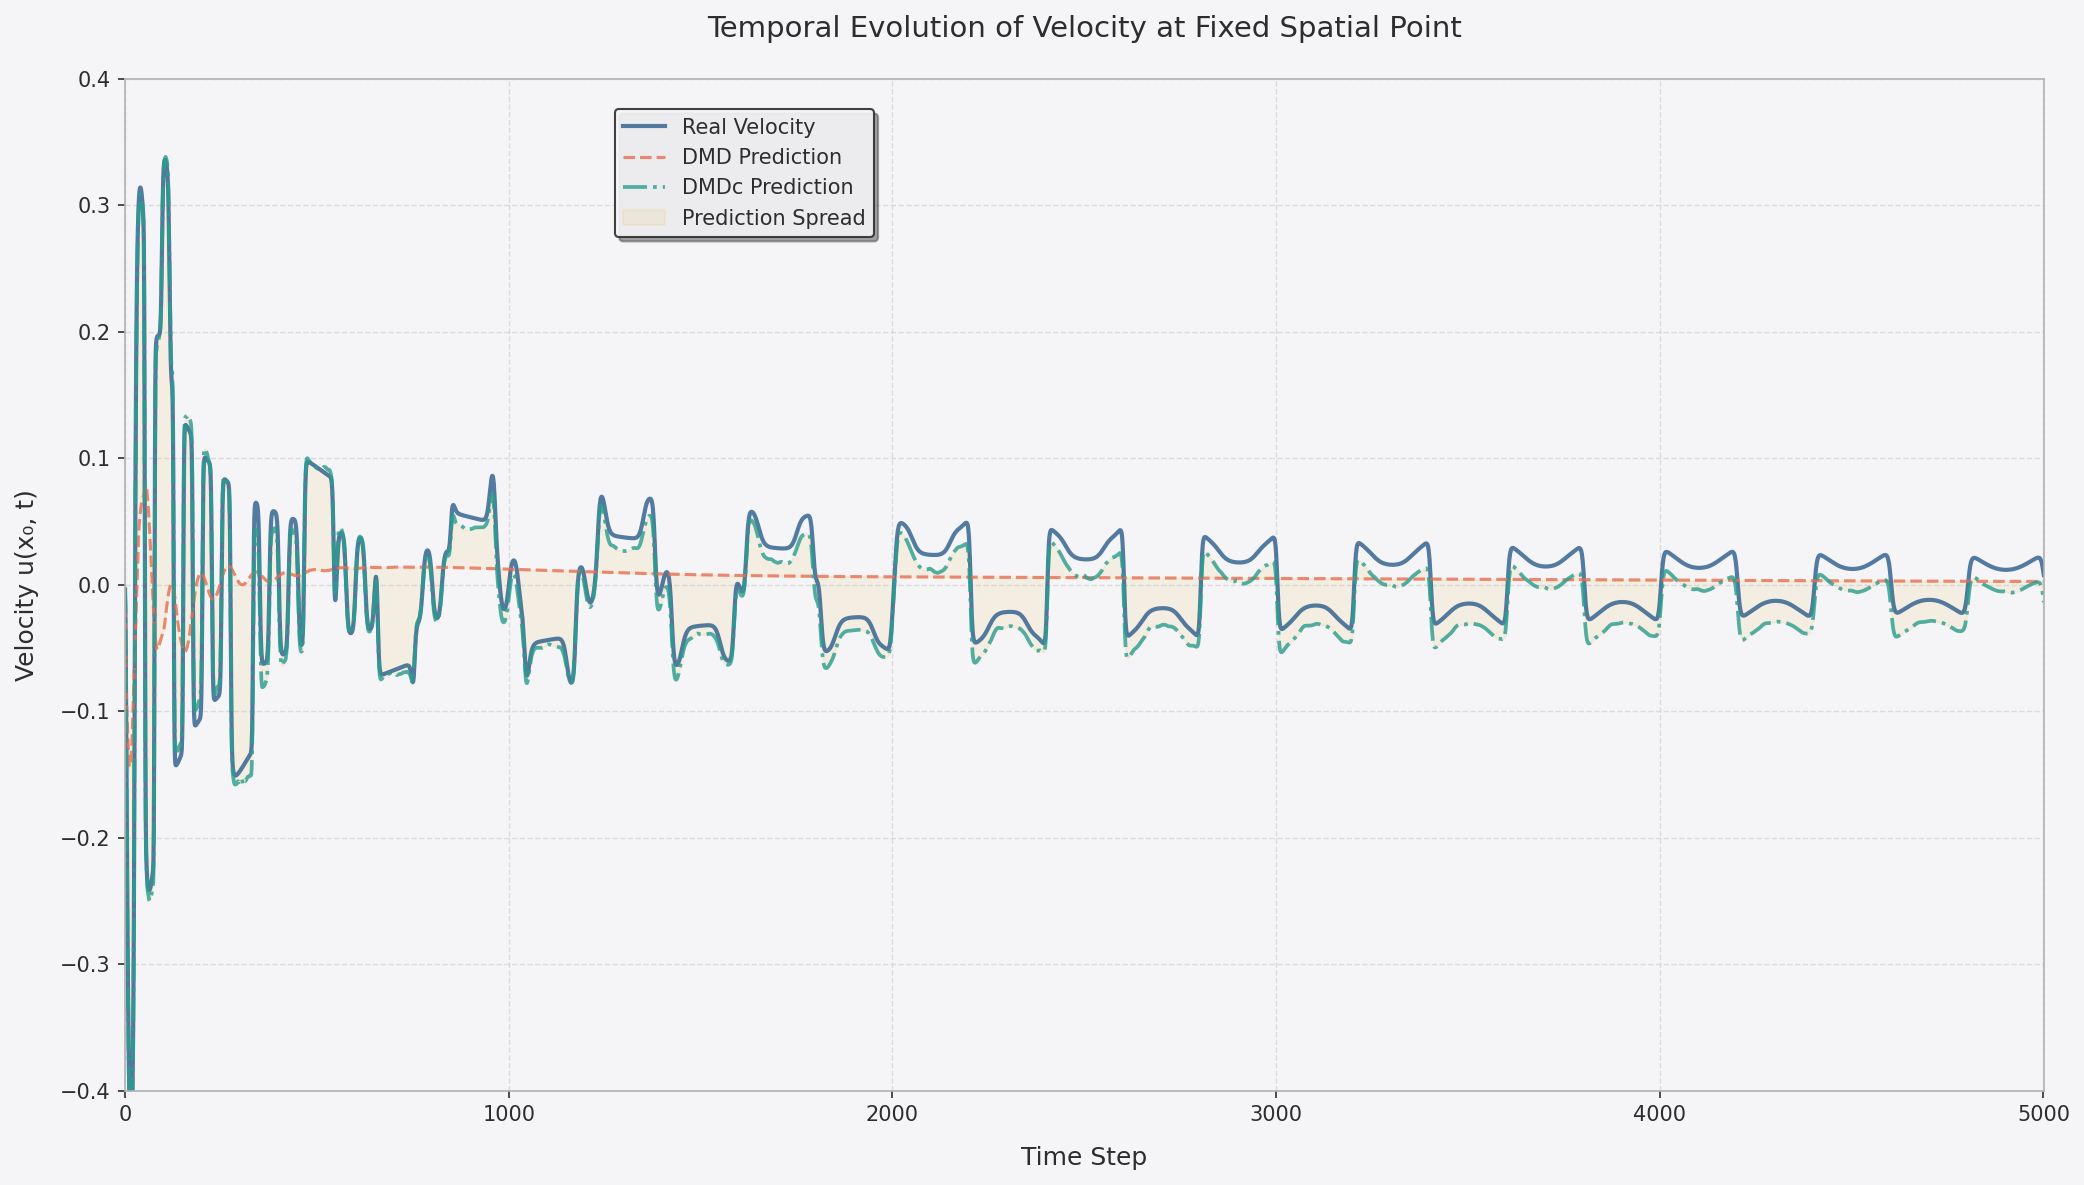

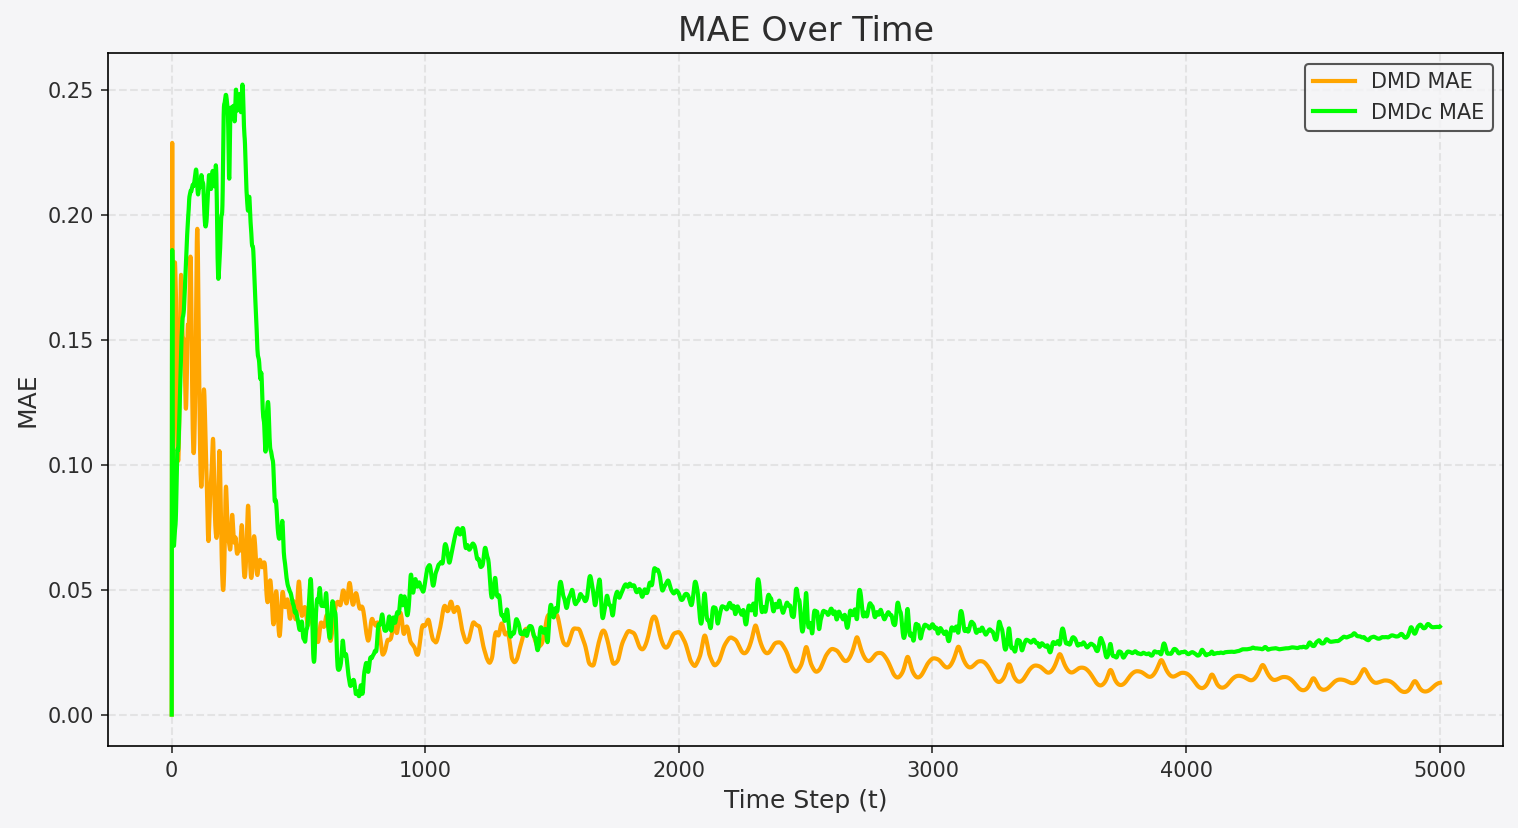

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import gaussian_filter


plt.rcParams['figure.facecolor'] = '#f5f5f7'
plt.rcParams['axes.facecolor'] = '#f5f5f7'
plt.rcParams['text.color'] = '#2d2d2d'
plt.rcParams['axes.labelcolor'] = '#2d2d2d'
plt.rcParams['xtick.color'] = '#2d2d2d'
plt.rcParams['ytick.color'] = '#2d2d2d'
plt.rcParams['legend.facecolor'] = '#f5f5f7'
plt.rcParams['legend.edgecolor'] = '#2d2d2d'


def safe_mape(y_true, y_pred, epsilon=1e-6):
    mask = np.abs(y_true) > epsilon
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.any() else np.inf


def custom_dmdc(X, I, svd_rank, alpha=1e-4):
    n_snapshots = X.shape[1]
    assert I.shape[1] == n_snapshots - 1, ''

    X1 = X[:, :-1]
    X2 = X[:, 1:]

    Omega = np.vstack((X1, I))

    U, S, Vt = np.linalg.svd(Omega, full_matrices=False)
    r = min(svd_rank, len(S))
    S_threshold = S[0] * 1e-8
    S[S < S_threshold] = S_threshold
    U = U[:, :r]
    S = np.diag(S[:r])
    Vt = Vt[:r, :]

    Ux = U[:X1.shape[0], :]
    Ub = U[X1.shape[0]:, :]

    U_x2, S_x2, Vt_x2 = np.linalg.svd(X2, full_matrices=False)
    r_x2 = min(svd_rank, len(S_x2))
    S_x2_threshold = S_x2[0] * 1e-8
    S_x2[S_x2 < S_x2_threshold] = S_x2_threshold
    U_x2 = U_x2[:, :r_x2]
    S_x2 = np.diag(S_x2[:r_x2])
    Vt_x2 = Vt_x2[:r_x2, :]

    # we gonna add Tikhonov regularization for stability
    S_inv_reg = np.linalg.pinv(S**2 + alpha * np.eye(r)) @ S
    A_tilde = U_x2.T @ X2 @ Vt.T @ S_inv_reg @ Ux.T @ U_x2
    B_tilde = U_x2.T @ X2 @ Vt.T @ S_inv_reg @ Ub.T

    return U_x2, A_tilde, B_tilde


def custom_dmd(X, svd_rank):
    X1 = X[:, :-1]
    X2 = X[:, 1:]

    U, S, Vt = np.linalg.svd(X1, full_matrices=False)
    r = min(svd_rank, len(S))
    S_threshold = S[0] * 1e-8
    S[S < S_threshold] = S_threshold
    U = U[:, :r]
    S = np.diag(S[:r])
    Vt = Vt[:r, :]

    A_tilde = U.T @ X2 @ Vt.T @ np.linalg.pinv(S)

    eigenvalues, W = np.linalg.eig(A_tilde)
    modes = U @ W

    return modes, eigenvalues


print("Loading data...")
U = np.loadtxt("velocity.txt")
P = np.loadtxt("pressure.txt")
print(f"U shape: {U.shape}")
print(f"P shape: {P.shape}")


U_denoised = gaussian_filter(U, sigma=1)
P_denoised = gaussian_filter(P, sigma=1)


scaler_U = StandardScaler()
scaler_P = StandardScaler()
U_normalized = scaler_U.fit_transform(U_denoised.T).T
P_normalized = scaler_P.fit_transform(P_denoised.T).T


n_x, n_t = U.shape
X = U_normalized
P_control = P_normalized[:, :-1]


svd_ranks = [100, 125, 150]
u_pred_dmd_ensemble = np.zeros_like(U_normalized)

for svd_rank in svd_ranks:
    start_time_dmd = time.time()
    dmd_modes, dmd_eigs = custom_dmd(X, svd_rank)
    fit_time_dmd = time.time() - start_time_dmd

    X_current_dmd = np.linalg.pinv(dmd_modes) @ X[:, 0].reshape(-1, 1)

    start_time_pred_dmd = time.time()
    u_pred_dmd = [X[:, 0].copy()]
    for t in range(1, n_t):
        X_current_dmd = dmd_eigs.reshape(-1, 1) * X_current_dmd
        pred = np.real(dmd_modes @ X_current_dmd)
        u_pred_dmd.append(pred.flatten())
    u_pred_dmd = np.array(u_pred_dmd).T
    pred_time_dmd = time.time() - start_time_pred_dmd

    u_pred_dmd_ensemble += scaler_U.inverse_transform(u_pred_dmd.T).T / len(svd_ranks)

u_pred_dmd = u_pred_dmd_ensemble
U_denorm = scaler_U.inverse_transform(U_normalized.T).T

mae_dmd = mean_absolute_error(U_denorm.flatten(), u_pred_dmd.flatten())
mape_dmd = safe_mape(U_denorm.flatten(), u_pred_dmd.flatten())


u_pred_dmdc_ensemble = np.zeros_like(U_normalized)

for svd_rank in svd_ranks:
    start_time_dmdc = time.time()
    modes, A_tilde, B_tilde = custom_dmdc(X, P_control, svd_rank, alpha=1e-4)
    fit_time_dmdc = time.time() - start_time_dmdc

    print(f"svd_rank: {svd_rank}, A_tilde shape: {A_tilde.shape}")
    print(f"B_tilde shape: {B_tilde.shape}")
    print(f"modes shape: {modes.shape}")

    X_current_dmdc = np.linalg.pinv(modes) @ X[:, 0].reshape(-1, 1)

    start_time_pred_dmdc = time.time()
    u_pred_dmdc = [X[:, 0].copy()]
    for t in range(1, n_t):
        P_control_t = P_normalized[:, t-1].reshape(-1, 1)
        X_next = A_tilde @ X_current_dmdc + B_tilde @ P_control_t
        pred = np.real(modes @ X_next)
        u_pred_dmdc.append(pred.flatten())
        X_current_dmdc = X_next
    u_pred_dmdc = np.array(u_pred_dmdc).T
    pred_time_dmdc = time.time() - start_time_pred_dmdc

    u_pred_dmdc_ensemble += scaler_U.inverse_transform(u_pred_dmdc.T).T / len(svd_ranks)

u_pred_dmdc = u_pred_dmdc_ensemble

mae_dmdc = mean_absolute_error(U_denorm.flatten(), u_pred_dmdc.flatten())
mape_dmdc = safe_mape(U_denorm.flatten(), u_pred_dmdc.flatten())


print(f"DMD MAE: {mae_dmd:.6f}, MAPE: {mape_dmd:.6f}%")
print(f"DMD Training Time: {fit_time_dmd:.6f} seconds, Prediction Time: {pred_time_dmd:.6f} seconds")
print(f"DMDc MAE: {mae_dmdc:.6f}, MAPE: {mape_dmdc:.6f}%")
print(f"DMDc Training Time: {fit_time_dmdc:.6f} seconds, Prediction Time: {pred_time_dmdc:.6f} seconds")


x = np.linspace(-10, 10, n_x)
t = np.arange(0, n_t)
vmin, vmax = -0.4, 0.4


plt.figure(figsize=(18, 12), dpi=150)
im = plt.imshow(U_denorm.T, aspect='auto', extent=[x[0], x[-1], t[-1], t[0]], cmap='coolwarm', vmin=vmin, vmax=vmax)
contours = plt.contour(x, t, U_denorm.T, levels=[-0.4, -0.2, 0, 0.2, 0.4], colors='white', alpha=0.7, linewidths=1)
plt.clabel(contours, inline=True, fmt='%1.1f', fontsize=10, colors='white')
plt.colorbar(im, ticks=[-0.4, -0.2, 0, 0.2, 0.4], label='Velocity (u)')
plt.title('True Velocity u(x,t)', fontsize=16)
plt.xlabel('x', fontsize=12)
plt.ylabel('Time Step (t)', fontsize=12)
plt.grid(True, color='lightgrey', linestyle='--', linewidth=1, alpha=0.5)
plt.show()


plt.figure(figsize=(18, 12), dpi=150)
im = plt.imshow(u_pred_dmd.T, aspect='auto', extent=[x[0], x[-1], t[-1], t[0]], cmap='coolwarm', vmin=vmin, vmax=vmax)
contours = plt.contour(x, t, u_pred_dmd.T, levels=[-0.4, -0.2, 0, 0.2, 0.4], colors='white', alpha=0.7, linewidths=1)
plt.clabel(contours, inline=True, fmt='%1.1f', fontsize=10, colors='white')
plt.colorbar(im, ticks=[-0.4, -0.2, 0, 0.2, 0.4], label='Velocity (u)')
plt.title('DMD Predicted Velocity u(x,t)', fontsize=16)
plt.xlabel('x', fontsize=12)
plt.ylabel('Time Step (t)', fontsize=12)
plt.grid(True, color='lightgrey', linestyle='--', linewidth=1, alpha=0.5)
plt.show()

plt.figure(figsize=(18, 12), dpi=150)
im = plt.imshow(u_pred_dmdc.T, aspect='auto', extent=[x[0], x[-1], t[-1], t[0]], cmap='coolwarm', vmin=vmin, vmax=vmax)
contours = plt.contour(x, t, u_pred_dmdc.T, levels=[-0.4, -0.2, 0, 0.2, 0.4], colors='white', alpha=0.7, linewidths=1)
plt.clabel(contours, inline=True, fmt='%1.1f', fontsize=10, colors='white')
plt.colorbar(im, ticks=[-0.4, -0.2, 0, 0.2, 0.4], label='Velocity (u)')
plt.title('DMDc Predicted Velocity u(x,t)', fontsize=16)
plt.xlabel('x', fontsize=12)
plt.ylabel('Time Step (t)', fontsize=12)
plt.grid(True, color='lightgrey', linestyle='--', linewidth=1, alpha=0.5)
plt.show()


x0_index = 500
time_steps = np.arange(0, 5002)

plt.figure(figsize=(14, 8), dpi=150)
plt.plot(time_steps, U_denorm[x0_index],
         label='Real Velocity',
         color='#2a5c8a',
         linewidth=2,
         alpha=0.8)

plt.plot(time_steps, u_pred_dmd[x0_index],
         label='DMD Prediction',
         color='#e76f51',
         linestyle='--',
         linewidth=1.5,
         alpha=0.8)

plt.plot(time_steps, u_pred_dmdc[x0_index],
         label='DMDc Prediction',
         color='#2a9d8f',
         linestyle='-.',
         linewidth=1.8,
         alpha=0.8)


plt.fill_between(time_steps,
                 u_pred_dmd[x0_index],
                 u_pred_dmdc[x0_index],
                 color='#e9c46a',
                 alpha=0.15,
                 label='Prediction Spread')

plt.ylim(-0.4, 0.4)
plt.xlim(0, 5001)
plt.title('Temporal Evolution of Velocity at Fixed Spatial Point',
          fontsize=14, pad=20, color='#2d2d2d')
plt.xlabel('Time Step', fontsize=12, labelpad=10)
plt.ylabel('Velocity u(x₀, t)', fontsize=12, labelpad=10)
plt.grid(True, color='#d1d1d1', linestyle='--', linewidth=0.7, alpha=0.7)


legend = plt.legend(fontsize=10,
                    frameon=True,
                    shadow=True,
                    edgecolor='#2d2d2d',
                    bbox_to_anchor=(0.25, 0.98),
                    loc='upper left')
legend.get_frame().set_alpha(0.9)


for spine in plt.gca().spines.values():
    spine.set_color('#b1b1b1')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()

mae_dmd_time = np.mean(np.abs(U_denorm - u_pred_dmd), axis=0)
mae_dmdc_time = np.mean(np.abs(U_denorm - u_pred_dmdc), axis=0)

plt.figure(figsize=(12, 6), dpi=150)
plt.plot(t, mae_dmd_time, label='DMD MAE', color='orange', linewidth=2)
plt.plot(t, mae_dmdc_time, label='DMDc MAE', color='lime', linewidth=2)
plt.title('MAE Over Time', fontsize=16)
plt.xlabel('Time Step (t)', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, color='lightgrey', linestyle='--', linewidth=1, alpha=0.5)
plt.show()